<a href="https://colab.research.google.com/github/furibeguerra/Vision_por_computadora_II/blob/main/Modelo_II_Resnet_50.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MODELO CON RESNET 50 (Incluido Data Aumengtation)





#Desarrollo

## Fabian Caihuara
## Fabian Uribe

In [ ]:
#Libreria para leer datos directamente desde kaggle
!pip install kaggle opendatasets

In [ ]:
from google.colab import files
files.upload() # Cargar el archivo kaggle.json

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"fabiancaihuarasossa2","key":"dc20941cf36d7027d0fbc04a02364f1a"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d feyzazkefe/trashnet
!unzip trashnet.zip -d trashnet_images

Dataset URL: https://www.kaggle.com/datasets/feyzazkefe/trashnet
License(s): unknown
  0% 0.00/40.8M [00:00<?, ?B/s]
100% 40.8M/40.8M [00:00<00:00, 932MB/s]
Archive:  trashnet.zip
  inflating: trashnet_images/dataset-resized/cardboard/cardboard1.jpg  
  inflating: trashnet_images/dataset-resized/cardboard/cardboard10.jpg  
  inflating: trashnet_images/dataset-resized/cardboard/cardboard100.jpg  
  inflating: trashnet_images/dataset-resized/cardboard/cardboard101.jpg  
  inflating: trashnet_images/dataset-resized/cardboard/cardboard102.jpg  
  inflating: trashnet_images/dataset-resized/cardboard/cardboard103.jpg  
  inflating: trashnet_images/dataset-resized/cardboard/cardboard104.jpg  
  inflating: trashnet_images/dataset-resized/cardboard/cardboard105.jpg  
  inflating: trashnet_images/dataset-resized/cardboard/cardboard106.jpg  
  inflating: trashnet_images/dataset-resized/cardboard/cardboard107.jpg  
  inflating: trashnet_images/dataset-resized/cardboard/cardboard108.jpg  
  inflati

In [ ]:
# ------------ Librerias necesarias
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.layers import Input, Activation, Add, Dense, Conv2D, GlobalAveragePooling2D, MaxPooling2D
from keras.layers import BatchNormalization, Dropout
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.optimizers import Adam
from keras.callbacks import ReduceLROnPlateau, EarlyStopping
from keras.models import Model
from keras.utils import plot_model
from sklearn.metrics import classification_report, confusion_matrix
# ----------------------------------------------------------------------------------------

## **Analisis de los datos** (EDA)
Despues de descargar la base de imagenes de kaggle en distintas carpetas, cada carpeta con el distinto tipo de basura o clusters del set de datos

metal carpeta contiene 410 imagenes.
plastic carpeta contiene 482 imagenes.
glass carpeta contiene 501 imagenes.
paper carpeta contiene 594 imagenes.
cardboard carpeta contiene 403 imagenes.
trash carpeta contiene 137 imagenes.

Todas las imagenes del set de datos son de tamaño: 512x384 con 3 banda de color.


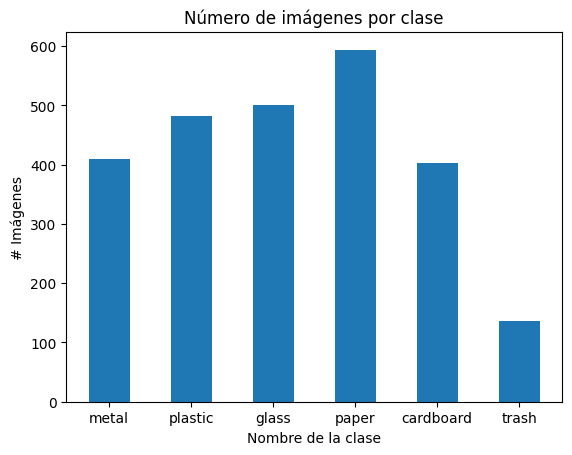

In [ ]:
# Path de las imagenes por categorias
dataset_path = 'trashnet_images/dataset-resized'

# Listado de categorias de basura
garbage_types = os.listdir(dataset_path)

# Analizar las dimensiones de las imagenes en cada carpeta de cada categoria
all_dimensions_set = set()
clusters = {}
for garbage_type in garbage_types:
    folder_path = os.path.join(dataset_path, garbage_type)
    if os.path.isdir(folder_path): #Validar si corresponde a una carpeta
        image_files = [f for f in os.listdir(folder_path) if f.endswith(('jpg', 'jpeg'))]
        num_images = len(image_files) #Contar imagenes en la carpeta
        clusters[garbage_type] = num_images
        print(f"{garbage_type} carpeta contiene {num_images} imagenes.")

        # Revisar dimensiones de las imagenes
        for image_file in image_files:
            image_path = os.path.join(folder_path, image_file)
            with Image.open(image_path) as img:
                width, height = img.size
                channels = len(img.getbands()) #Validamos las bandas de color de la imagen
                all_dimensions_set.add((width, height, channels))

# Validar la cantidad de cada tamaño de imagen y la banda de colores
if len(all_dimensions_set) == 1:
    width, height, channel = all_dimensions_set.pop()
    print(f"\nTodas las imagenes del set de datos son de tamaño: {width}x{height} con {channels} banda de color.")
else:
    print("\nLas imagenes tienen distintos tamaños o bandas de color")

# Grafica de la cantidad de imagenes por cada tipo

plt.bar(clusters.keys(), clusters.values(), width = .5);
plt.title("Número de imágenes por clase");
plt.xlabel('Nombre de la clase');
plt.ylabel('# Imágenes');

Conclusiones de la Distribución de Clases:
Se observa un desbalance significativo entre clases que puedan generar.
  - **Sesgo**: El modelo podría inclinarse a predecir papel con frecuencia por que tenemos mas muestras para el entrenamiento.
  - **Generalización**: En un escenario real los elementos "trash" son tan comunes como los elementos de tipo "paper".
  - **Precisión**: El modelo podria ser muy preciso para identificar la clase con mayores elementos.

Podriamos usar las siguientes técnicas para arreglarlo:
  - Data Augmentation selectivo por clase,
  - Uso de pesos de clase ('class_weights') durante el entrenamiento.
  - Sobremuestreo de clases minoritarias.
  - Submuestreo de clases mayoritarias.

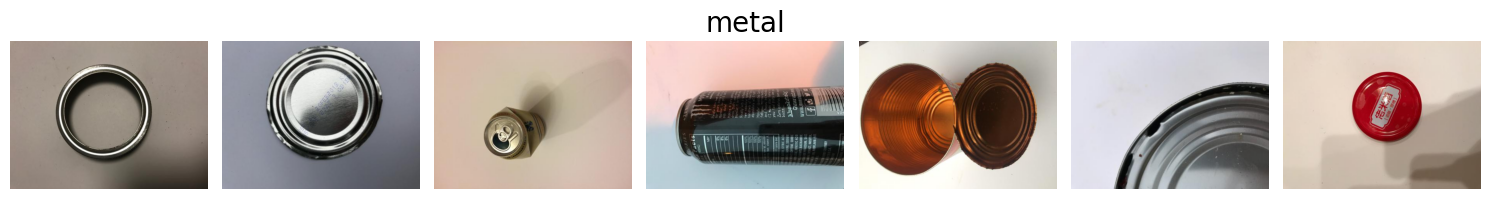

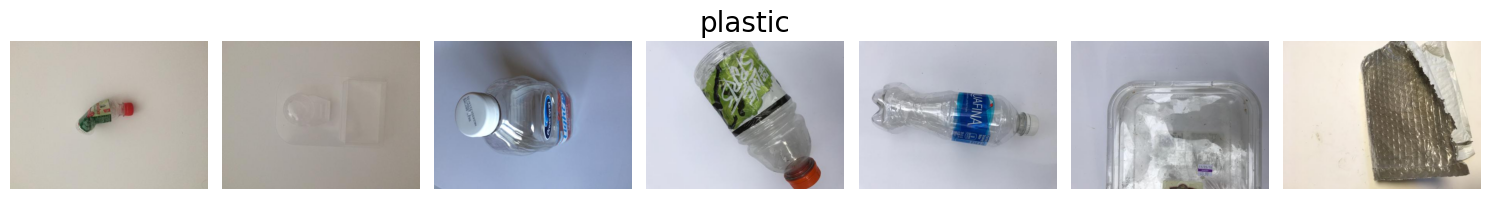

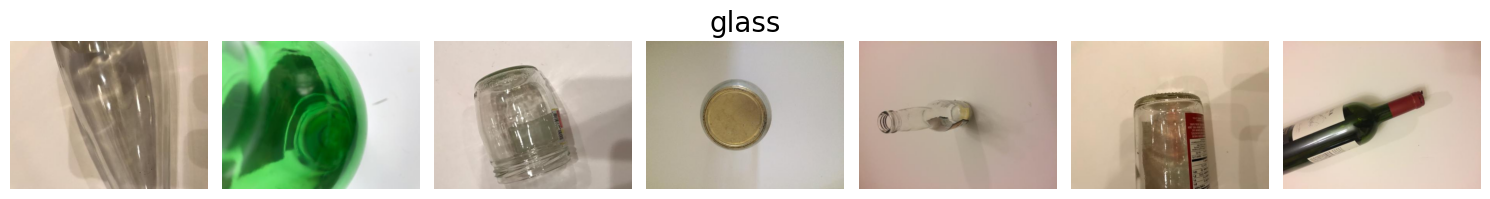

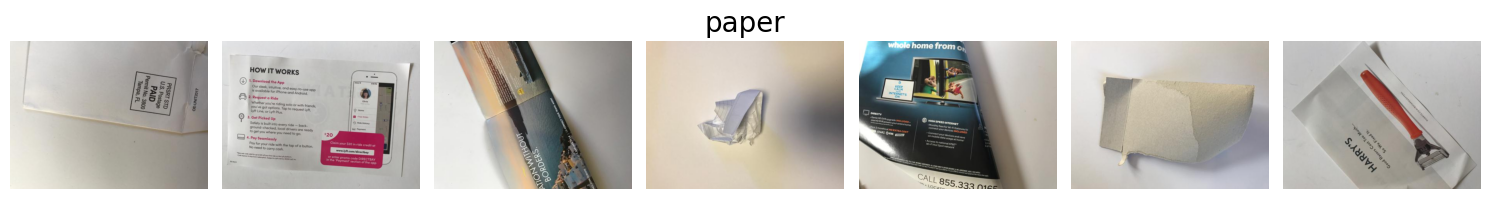

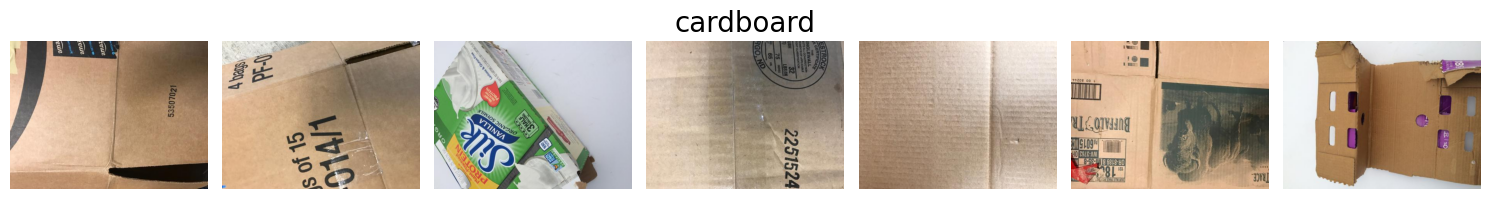

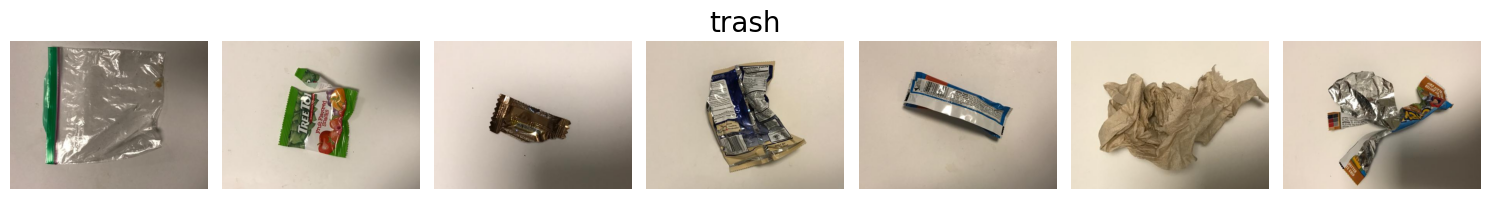

In [ ]:
# Visualizar algunas imagenes de cada clase
for garbage_type in garbage_types:
    folder_path = os.path.join(dataset_path, garbage_type)
    if os.path.isdir(folder_path):
        image_files = [f for f in os.listdir(folder_path) if f.endswith(('jpg', 'jpeg'))]
        image_files = image_files[:7] # Primeros 7 imagenes
        fig, axs = plt.subplots(1, 7, figsize=(15, 2))

        for i, image_file in enumerate(image_files):
            image_path = os.path.join(folder_path, image_file)
            with Image.open(image_path) as img:
                axs[i].imshow(img)
                axs[i].axis('off')

        plt.tight_layout()
        fig.suptitle(garbage_type, fontsize=20, y=1.03)
        plt.show()

1. **Variabilidad Intra-clase**:

¿Cuán diferentes son las imágenes dentro de la misma clase?

Basado en las imágenes mostradas, hay una variabilidad significativa dentro de cada clase:

*   Plastic: Se observan diferentes tipos de plásticos - envases transparentes,botellas verdes, envases blancos, etc.... Tienen diferentes formas, transparencias y texturas.
*   Trash: La variabilidad es alta, con diferentes objetos como bandejas de plástico, botellas aplastadas, y envases transparentes.
*   Papel y otros: También presentan variabilidad en colores, formas y texturas.

Esta alta variabilidad intra-clase es la que nos puede afectar durante el desarrollo de el modelo, ya que tiene que aprender características comunes que identifiquen una clase a pesar de estas diferencias.

2. **Similitud Inter-clase**:

¿Hay imágenes de diferentes clases que se parecen mucho?

Sí, existen similitudes entre algunas clases:

*   Plástico transparente vs. Vidrio: Ambos pueden tener apariencia similar, transparente y brillante.
*   Plástico blanco vs. Papel: Algunas bolsas de plástico blanco pueden confundirse con papel desde ciertos ángulos.
*   Bandejas de plástico vs. bandejas de cartón: Su forma puede ser similar aunque el material sea distinto.

Estas similitudes representan otro desafío para el modelo, ya que necesitariamos que aprendiera a distinguir sutiles diferencias en textura y reflejo de luz para diferenciar materiales similares.

3. **Calidad de imagen**:

Las imágenes mostradas tienen:

*   Buena nitidez: La mayoría son nítidas y se pueden distinguir detalles
Iluminación variable: Algunas tienen buena iluminación mientras que otras presentan sombras o reflejos
*   Fondos consistentes: Casi todas tienen un fondo blanco/gris uniforme, lo que es positivo
*   Ángulos diversos: Los objetos están fotografiados desde diferentes ángulos y posiciones

## **Preparación de los datos**

In [ ]:
data = [] # Lista

# Obtener el listado de direcciones
for garbage_type in garbage_types:
    for file in os.listdir(os.path.join(dataset_path, garbage_type)):
        data.append((os.path.join(dataset_path, garbage_type, file), garbage_type))

df = pd.DataFrame(data, columns=['filepath', 'label']) # Dataframe

df.head()

,filepath,label
0,trashnet_images/dataset-resized/metal/metal181...,metal
1,trashnet_images/dataset-resized/metal/metal140...,metal
2,trashnet_images/dataset-resized/metal/metal3.jpg,metal
3,trashnet_images/dataset-resized/metal/metal137...,metal
4,trashnet_images/dataset-resized/metal/metal189...,metal


Para garantizar una representacion correcta de las clases tomando en cuenta la distribución del total de conjunto de imagenes.

Se usará un muestreo con la función **train_test_split** que ayuda mantener la proporción de clases del dataset total.

In [ ]:
# División de los datos
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

print(f"Número de imagenes en training set: {len(train_df)}")
print(f"Número de imagenes en validation set: {len(val_df)}")

Número de imagenes en training set: 2021
Número de imagenes en validation set: 506


In [ ]:
# 1. Ditribución total dataset
overall_distribution = df['label'].value_counts(normalize=True) * 100

# 2. Distribución training set
train_distribution = train_df['label'].value_counts(normalize=True) * 100

# 3. Distribución validation set
val_distribution = val_df['label'].value_counts(normalize=True) * 100

print("Ditribución total dataset:\n")
print(overall_distribution.round(2))
print('-'*40)

print("\nDistribución training set:\n")
print(train_distribution.round(2))
print('-'*40)

print("\nDistribución validation set:\n")
print(val_distribution.round(2))

Ditribución total dataset:

label
paper        23.51
glass        19.83
plastic      19.07
metal        16.22
cardboard    15.95
trash         5.42
Name: proportion, dtype: float64
----------------------------------------

Distribución training set:

label
paper        23.50
glass        19.84
plastic      19.05
metal        16.23
cardboard    15.93
trash         5.44
Name: proportion, dtype: float64
----------------------------------------

Distribución validation set:

label
paper        23.52
glass        19.76
plastic      19.17
metal        16.21
cardboard    16.01
trash         5.34
Name: proportion, dtype: float64


Se observa que la distribución se mantiene en la división del dataset.

## **Data Augmentation & Rescaling**

- Tomando en cuenta la cantidad de imagenes limitadas, se aplicará algoritmo de data augmentation para generar "nuevos" ejemplos de datos de entrenamiento.
- Tomar en cuenta que una red neuronal trabaja de mejor manera con valores entre 0 y 1  el Rescaling en las imagenes nos permitira un mejor desempeño.

Basado en el set de datos se observa que se puede aplicar Data Augmentation tomando en cuenta las siguientes caracteristicas de las imagenes:

-**Rescaling**: Normalizar valores entre 0 y 1.

-**Rotación**

-**Ancho&Alto desplazamiento**

-**Zoom**

-**Orientacion**

-**Ajuste de brillo**

-**Variacion de canales de colores**

-**Relleno de pixeles faltantes**


In [ ]:
# Data Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,                     # Normalizar [0,1]
    rotation_range=45,                  # Aleatoria rotacion 45 grados
    width_shift_range=0.15,             # Aleatorio desplazamiento horizontal del 15%
    height_shift_range=0.15,            # Aleatorio desplazamiento vertical del 15%
    zoom_range=0.15,                    # Aleatorio zoom del 15%
    horizontal_flip=True,               # Aleatorio orientacion horizontal
    vertical_flip=True,                 # Aleatorio orientacion vertical
    shear_range=0.05,                   # Aplicar cortes
    brightness_range=[0.9, 1.1],        # Variacion ajuste de brillo entre 90% a 110%
    channel_shift_range=10,             # Aleatorio variación de canales de colores
    fill_mode='nearest'                 # Rellenar pixeles faltantes con datos de pixeles vecinos
)

val_datagen = ImageDataGenerator(rescale=1./255)

- Usar **flow_from_dataframe** para generar batches directamente desde el dataframe.
- Redimensionar las imagenes a un formato cuadrado de 384x384 para mantener una buen desempeño del CNN.
- Utilizar una semilla de cero durante el data augmentation para garantizar la reproducibilidad de las transformaciones en el tiempo.

In [ ]:
# Usando flow_from_dataframe para generar batches
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="filepath",
    y_col="label",
    target_size=(384, 384),              # Ajustar el tamaño a 384x384
    batch_size=32,                       # Numero de imagenes por batch
    class_mode='categorical',
    seed=42,                             # Semilla
    shuffle=False
)
val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="filepath",
    y_col="label",
    target_size=(384, 384),              # Ajustar el tamaño a 384x384
    batch_size=32,                       # Numero de imagenes por batch
    class_mode='categorical',
    seed=42,                             # Semilla
    shuffle=False
)
print(f"Numero de batches en train_generator: {len(train_generator)}")
print(f"Numero de batches en val_generator: {len(val_generator)}")

Found 2021 validated image filenames belonging to 6 classes.
Found 506 validated image filenames belonging to 6 classes.
Numero de batches en train_generator: 64
Numero de batches en val_generator: 16


Al usar el metodo **flow_from_dataframe** no se pregeneran todas las transformaciones solo configuramos el framework.

La ventaja de **ImageDataGeneration** es generar las imagenes durante la ejecucion de cada **step** lo que permite no necesraiamente tenerlas almacenadas

Para abordar el problema de desequilibrio en nuestro conjunto de datos de imágenes, utilizaremos pesos de clase durante el entrenamiento del modelo. Los pesos de clase permiten mitigar el sesgo hacia las clases mayoritarias, asignando mayor importancia a las clases menos representadas. Esta técnica es especialmente útil en tareas de clasificación como es el caso del dataset donde algunas categorías tienen muchas menos muestras que otras.

Los pesos se calculan usando la función **compute_class_weight** del módulo **sklearn.utils.class_weight** de scikit-learn. Esta utilidad calcula los pesos de forma inversamente proporcional a la frecuencia de cada clase, asegurando que las clases con menos muestras tengan un mayor impacto en la función de pérdida.

El peso de cada clase se calcula como: $w_i = \frac{n}{k \cdot n_i}$

$w_i$: peso de la clase i

n: número total de muestras

k: número total de clases

$n_i$: cantidad de muestras en la clase i

In [ ]:
# Extraer las clases
class_labels = train_df['label'].unique()
class_labels
train_generator.class_indices
# Calcular los pesos
weights = compute_class_weight(class_weight='balanced', classes=class_labels, y=train_df['label'])
class_weights = dict(zip(train_generator.class_indices.values(), weights)) #Variable para pasar el modelo
display(class_weights)

{0: np.float64(3.062121212121212),
 1: np.float64(0.8399833748960931),
 2: np.float64(0.7091228070175438),
 3: np.float64(1.026930894308943),
 4: np.float64(0.8748917748917749),
 5: np.float64(1.0460662525879918)}

- **'cardboard'** = 0

- **'glass'** = 1

- **'metal'** = 2

- **'paper'** = 3

- **'plastic'** = 4

- **'trash'** = 5

## **Construcción modelo de clasificación ResNet50**

La característica distintiva de las arquitecturas ResNet es la introducción de conexiones residuales, también conocidas como "skip connections" o "shortcut connections".

Estas conexiones permiten que la señal de entrada de un bloque de capas salte directamente a una capa más adelante, saltándose una o varias capas intermedias, sin pasar por todo el procesamiento de convoluciones. Esto se representa matemáticamente como:

                  $Output = 𝐹(x) + x $

Donde:

$F(x)$ es la transformación realizada por las capas convolucionales intermedias.

$x$ es la entrada del bloque.


En redes muy profundas, es común enfrentar el problema del gradiente desvanecido (vanishing gradient), donde los gradientes se vuelven tan pequeños que no logran actualizar los pesos durante el entrenamiento. Esto impide que las redes aprendan correctamente al aumentar su profundidad.

Las conexiones residuales resuelven este problema al:

- Permitir que el gradiente fluya directamente hacia capas anteriores, sin atenuarse.

- Facilitar el aprendizaje de funciones de identidad (si el bloque no necesita modificar la información, simplemente deja pasar el input).

- Hacer posible el entrenamiento de redes mucho más profundas, como ResNet50 (con 50 capas), ResNet101 o incluso ResNet152.

**ResNet50** está compuesta por 49 capas convolucionales y 1 capa fully-connected final. Su estructura se basa en el uso de bloques residuales llamados "Bottleneck Blocks", que constan de tres capas:

Convolución 1x1 (reducción de dimensión)

Convolución 3x3

Convolución 1x1 (expansión de dimensión)

Cada uno de estos bloques incluye una conexión residual que suma la entrada original al resultado final del bloque. Si las dimensiones no coinciden, se agrega una proyección (convolución 1x1) para ajustar el tamaño.

Un bloque residual básico se representa así:


            Entrada (x)
               │
               ▼
       ┌───────────────────┐
       │   Conv 1x1        │
       │ BatchNorm + ReLU  │
       └───────────────────┘
               │
               ▼
       ┌───────────────────┐
       │   Conv 3x3        │
       │ BatchNorm + ReLU  │
       └───────────────────┘
               │
               ▼
       ┌───────────────────┐
       │   Conv 1x1        │
       │   BatchNorm       │
       └───────────────────┘
               │
               ▼
    ┌───────────────────────────┐
    │        Suma con x         │◄────────────┐
    └───────────────────────────┘             │
               │                              │
               ▼                              │
             ReLU                             │
               │                              │
               ▼                              │
           Salida                             │
                                              │
 (si las dimensiones no coinciden, aplicar Conv1x1 a x)

In [ ]:
def residual_block(X, kernel_size, filters, reduce=False, stride=2):
    """
    Implement a residual block for ResNet architectures.

    Arguments:
    X           -- input tensor of shape (m, height, width, channels)
    kernel_size -- integer, kernel size of the middle convolutional layer in the main path
    filters     -- python list of integers, defining the number of filters in the CONV layers of the main path
    reduce      -- boolean, whether to reduce the spatial dimensions and increase depth;
                    if True, applies 1x1 CONV layer to the shortcut path.
    stride      -- integer, strides for the convolutional layer

    Returns:
    X           -- output of the identity block, tensor of shape (height, width, channels)
    """

    # Retrieve Filters
    F1, F2, F3 = filters

    # Save the input value. We will need this later to add back to the main path.
    X_shortcut = X

    if reduce:
        # if we are to reduce the spatial size, apply a 1x1 CONV layer to the shortcut path
        X = Conv2D(filters = F1, kernel_size = (1, 1), strides = (stride,stride), padding = 'valid', kernel_initializer='he_normal')(X)
        X = BatchNormalization(axis = 3)(X)
        X = Activation('relu')(X)

        X_shortcut = Conv2D(filters = F3, kernel_size = (1, 1), strides = (stride,stride), padding = 'valid', kernel_initializer='he_normal')(X_shortcut)
        X_shortcut = BatchNormalization(axis = 3)(X_shortcut)
    else:
        # First component of main path
        X = Conv2D(filters = F1, kernel_size = (1, 1), strides = (1,1), padding = 'valid', kernel_initializer='he_normal')(X)
        X = BatchNormalization(axis = 3)(X)
        X = Activation('relu')(X)

    # Second component of main path
    X = Conv2D(filters = F2, kernel_size = (kernel_size, kernel_size), strides = (1,1), padding = 'same', kernel_initializer='he_normal')(X)
    X = BatchNormalization(axis = 3)(X)
    X = Activation('relu')(X)

    # Third component of main path
    X = Conv2D(filters = F3, kernel_size = (1, 1), strides = (1,1), padding = 'valid', kernel_initializer='he_normal')(X)
    X = BatchNormalization(axis = 3)(X)

    # Final step: Add shortcut value to main path, and pass it through a ReLU activation
    X = Add()([X, X_shortcut])
    X = Activation('relu')(X)

    return X

En algunos casos, dentro de un **bloque residual**, es necesario **ajustar la profundidad (número de canales)** o incluso las **dimensiones espaciales** (alto y ancho) del mapa de características. Para lograrlo, se utiliza una **capa de convolución 1x1** en el camino de acceso directo o **shortcut** (es decir, cuando reduce=True).

Esta convolución 1x1 cumple dos propósitos:

- **Ajusta el número de canales** para que coincidan con la salida del bloque principal.

- **Cambia el tamaño del mapa de características** (altura y anchura) cuando es necesario, utilizando un stride mayor a 1.

Sin embargo, para poder sumar correctamente los mapas de características del camino principal y del camino shortcut (conexión residual), ambos deben tener exactamente el mismo tamaño.

Por esta razón, cuando se modifica el tamaño espacial del mapa (por ejemplo, usando stride=2 para reducir altura y anchura), la primera convolución 1x1 del camino principal y la convolución 1x1 del shortcut deben usar el mismo stride. Esto asegura que ambas salidas tengan las mismas dimensiones y puedan sumarse sin errores.

In [ ]:
def ResNet_50(input_shape, classes):
    """
    Arguments:
    input_shape -- tuple shape of the images of the dataset
    classes -- integer, number of classes

    Returns:
    model -- a Model() instance in Keras
    """

    # Define the input as a tensor with shape input_shape
    X_input = Input(input_shape)

    # Block 1
    X = Conv2D(64, (7, 7), strides=(2, 2), kernel_initializer='he_normal')(X_input)
    X = BatchNormalization(axis=3)(X)
    X = Activation('relu')(X)
    X = MaxPooling2D((3, 3), strides=(2, 2))(X)

    # Block 2
    X = residual_block(X, 3, [64, 64, 256], reduce=True, stride=1)
    X = residual_block(X, 3, [64, 64, 256])
    X = residual_block(X, 3, [64, 64, 256])

    # Block 3
    X = residual_block(X, 3, [128, 128, 512], reduce=True, stride=2)
    X = residual_block(X, 3, [128, 128, 512])
    X = residual_block(X, 3, [128, 128, 512])
    X = residual_block(X, 3, [128, 128, 512])

    # Block 4
    X = residual_block(X, 3, [256, 256, 1024], reduce=True, stride=2)
    X = residual_block(X, 3, [256, 256, 1024])
    X = residual_block(X, 3, [256, 256, 1024])
    X = residual_block(X, 3, [256, 256, 1024])
    X = residual_block(X, 3, [256, 256, 1024])
    X = residual_block(X, 3, [256, 256, 1024])

    # Block 5
    X = residual_block(X, 3, [512, 512, 2048], reduce=True, stride=2)
    X = residual_block(X, 3, [512, 512, 2048])
    X = residual_block(X, 3, [512, 512, 2048])

    # Global Average Pooling to reduce spatial dimensions
    X = GlobalAveragePooling2D()(X)

    # Fully Connected Layer for classification
    X = Dense(classes, activation='softmax')(X)

    # Create the model
    model = Model(inputs = X_input, outputs = X, name='ResNet50')

    return model

Dado el **diseño complejo de ResNet50** y el hecho de que contamos con un **conjunto de datos pequeño**, el modelo tiende a **sobreajustarse** (overfitting) a los datos de entrenamiento. Es decir, aprende demasiado bien los ejemplos vistos, pero pierde capacidad de generalizar a datos nuevos o no vistos.

Para mitigar este problema, **se modifica ligeramente la arquitectura de ResNet**, introduciendo una capa de **Dropout** justo después de la capa **GlobalAveragePooling2D**.

La capa **GlobalAveragePooling2D** reemplaza las capas fully-connected tradicionales, resumiendo cada mapa de características a un único valor promedio.

Al agregar una capa **Dropout** después, forzamos al modelo a **"apagar aleatoriamente" ciertas neuronas** durante el entrenamiento. Esto:

- Reduce la dependencia excesiva de ciertas características.

- Actúa como una forma de regularización, ayudando a prevenir el sobreajuste.

- Promueve un aprendizaje más robusto y generalizable.

Ubicar el **Dropout** justo después de la GlobalAveragePooling2D es efectivo porque:

Es el paso justo antes de la capa final de clasificación.

En ese punto, el modelo ya ha extraído las características más relevantes, y el Dropout actúa sobre ese resumen, ayudando a evitar que se memoricen patrones específicos del conjunto de entrenamiento.

In [ ]:
def Modified_ResNet50(input_shape, classes):
    """
    Arguments:
    input_shape -- tuple shape of the images of the dataset
    classes -- integer, number of classes

    Returns:
    model -- a Model() instance in Keras
    """

    # Define the input as a tensor with shape input_shape
    X_input = Input(input_shape)

    # Stage 1
    X = Conv2D(64, (7, 7), strides=(2, 2), kernel_initializer='he_normal')(X_input)
    X = BatchNormalization(axis=3)(X)
    X = Activation('relu')(X)
    X = MaxPooling2D((3, 3), strides=(2, 2))(X)

    # Stage 2
    X = residual_block(X, 3, [64, 64, 256], reduce=True, stride=1)
    X = residual_block(X, 3, [64, 64, 256])
    X = residual_block(X, 3, [64, 64, 256])

    # Stage 3
    X = residual_block(X, 3, [128, 128, 512], reduce=True, stride=2)
    X = residual_block(X, 3, [128, 128, 512])
    X = residual_block(X, 3, [128, 128, 512])
    X = residual_block(X, 3, [128, 128, 512])

    # Stage 4
    X = residual_block(X, 3, [256, 256, 1024], reduce=True, stride=2)
    X = residual_block(X, 3, [256, 256, 1024])
    X = residual_block(X, 3, [256, 256, 1024])
    X = residual_block(X, 3, [256, 256, 1024])
    X = residual_block(X, 3, [256, 256, 1024])
    X = residual_block(X, 3, [256, 256, 1024])

    # Stage 5
    X = residual_block(X, 3, [512, 512, 2048], reduce=True, stride=2)
    X = residual_block(X, 3, [512, 512, 2048])
    X = residual_block(X, 3, [512, 512, 2048])

    # Global Average Pooling to reduce spatial dimensions
    X = GlobalAveragePooling2D()(X)

    # Add Dropout to prevent overfitting
    X = Dropout(0.5)(X)

    # Fully Connected Layer for classification
    X = Dense(classes, activation='softmax')(X)

    # Create the model
    model = Model(inputs = X_input, outputs = X, name='Modified_ResNet50')

    return model

In [ ]:
# Define the shape of the input images and number of classes
input_shape = (384, 384, 3)
num_classes = 6

# Initialize the modified ResNet50 model with the specified parameters
modified_resnet50_model = Modified_ResNet50(input_shape=input_shape, classes=num_classes)

Por último, examinemos el resumen de nuestro modelo para comprender la cantidad de parámetros involucrados:

In [ ]:
modified_resnet50_model.summary()

Model: "Modified_ResNet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 384, 384,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 189, 189,  │      9,472 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 189, 189,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 189, 189,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 94, 94,    │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 94, 94,    │      4,160 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 94, 94,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 94, 94,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 94, 94,    │     36,928 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 94, 94,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 94, 94,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 94, 94,    │     16,640 │ activation_2[0][… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 94, 94,    │     16,640 │ max_pooling2d[0]… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 94, 94,    │      1,024 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 94, 94,    │      1,024 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 94, 94,    │          0 │ batch_normalizat… │
│                     │ 256)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 94, 94,    │          0 │ add[0][0]       

 Total params: 23,600,006 (90.03 MB)

 Trainable params: 23,546,886 (89.82 MB)

 Non-trainable params: 53,120 (207.50 KB)

## **Entrenamiento del modelo**

In [ ]:
modified_resnet50_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# Add ReduceLROnPlateau callback
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=15, min_lr=0.00001)

# Add EarlyStopping callback
early_stopping = EarlyStopping(monitor='val_loss', mode='min', patience=50, restore_best_weights=True, verbose=1)

In [ ]:
print(f"Number of batches in train_generator: {len(train_generator)}")
print(f"Number of batches in val_generator: {len(val_generator)}")

Number of batches in train_generator: 64
Number of batches in val_generator: 16


In [ ]:
print("Assigned Class Weights:")
class_weights

Assigned Class Weights:


{0: np.float64(3.062121212121212),
 1: np.float64(0.8399833748960931),
 2: np.float64(0.7091228070175438),
 3: np.float64(1.026930894308943),
 4: np.float64(0.8748917748917749),
 5: np.float64(1.0460662525879918)}

In [ ]:
# Total number of epochs
num_epochs = 200

# Train the model
history = modified_resnet50_model.fit(train_generator,
                                      steps_per_epoch=len(train_generator),
                                      epochs=num_epochs,
                                      validation_data=val_generator,
                                      validation_steps=len(val_generator),
                                      class_weight=class_weights,
                                      callbacks=[reduce_lr, early_stopping])

Epoch 1/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 226s 2s/step - accuracy: 0.3199 - loss: 2.8348 - val_accuracy: 0.1621 - val_loss: 355.5080 - learning_rate: 0.0010
Epoch 2/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 119s 2s/step - accuracy: 0.4714 - loss: 1.5973 - val_accuracy: 0.1858 - val_loss: 66.1509 - learning_rate: 0.0010
Epoch 3/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.4796 - loss: 1.4546 - val_accuracy: 0.1858 - val_loss: 759.9731 - learning_rate: 0.0010
Epoch 4/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.4824 - loss: 1.5389 - val_accuracy: 0.2470 - val_loss: 29.0969 - learning_rate: 0.0010
Epoch 5/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - accuracy: 0.5222 - loss: 1.2822 - val_accuracy: 0.1719 - val_loss: 545.7953 - learning_rate: 0.0010
Epoch 6/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 104s 2s/step - accuracy: 0.5171 - loss: 1.3284 - val_accuracy: 0.1759 - val_loss: 3.6744 - learning_rate: 0.0010
Epoch 7/200
38/64 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.5709 - loss: 1.

/usr/local/lib/python3.11/dist-packages/keras/src/legacy/preprocessing/image.py:1880: DeprecationWarning: Please import `affine_transform` from the `scipy.ndimage` namespace; the `scipy.ndimage.interpolation` namespace is deprecated and will be removed in SciPy 2.0.0.
  scipy.ndimage.interpolation.affine_transform(


64/64 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.5600 - loss: 1.2259 - val_accuracy: 0.1028 - val_loss: 8.0158 - learning_rate: 0.0010
Epoch 8/200
22/64 ━━━━━━━━━━━━━━━━━━━━ 1:07 2s/step - accuracy: 0.5683 - loss: 1.2171

/usr/local/lib/python3.11/dist-packages/keras/src/legacy/preprocessing/image.py:1880: DeprecationWarning: Please import `affine_transform` from the `scipy.ndimage` namespace; the `scipy.ndimage.interpolation` namespace is deprecated and will be removed in SciPy 2.0.0.
  scipy.ndimage.interpolation.affine_transform(


64/64 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.5551 - loss: 1.2343 - val_accuracy: 0.3478 - val_loss: 2.8177 - learning_rate: 0.0010
Epoch 9/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - accuracy: 0.5771 - loss: 1.1960 - val_accuracy: 0.4644 - val_loss: 1.8430 - learning_rate: 0.0010
Epoch 10/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.5667 - loss: 1.1609 - val_accuracy: 0.2055 - val_loss: 7.6108 - learning_rate: 0.0010
Epoch 11/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - accuracy: 0.5970 - loss: 1.0739 - val_accuracy: 0.2747 - val_loss: 4.2975 - learning_rate: 0.0010
Epoch 12/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 104s 2s/step - accuracy: 0.6274 - loss: 1.0912 - val_accuracy: 0.3162 - val_loss: 4.1036 - learning_rate: 0.0010
Epoch 13/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.6369 - loss: 0.9754 - val_accuracy: 0.5020 - val_loss: 1.3096 - learning_rate: 0.0010
Epoch 14/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - accuracy: 0.6420 - loss: 0.9079 - val_acc

...

64/64 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - accuracy: 0.7858 - loss: 0.5741 - val_accuracy: 0.5020 - val_loss: 2.5633 - learning_rate: 5.0000e-04
Epoch 41/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 145s 2s/step - accuracy: 0.7834 - loss: 0.5622 - val_accuracy: 0.6779 - val_loss: 1.0922 - learning_rate: 5.0000e-04
Epoch 42/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 138s 2s/step - accuracy: 0.7639 - loss: 0.6218 - val_accuracy: 0.6640 - val_loss: 1.4575 - learning_rate: 5.0000e-04
Epoch 43/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - accuracy: 0.8163 - loss: 0.5219 - val_accuracy: 0.5455 - val_loss: 1.8250 - learning_rate: 5.0000e-04
Epoch 44/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 107s 2s/step - accuracy: 0.7986 - loss: 0.5376 - val_accuracy: 0.5632 - val_loss: 1.7093 - learning_rate: 5.0000e-04
Epoch 45/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 108s 2s/step - accuracy: 0.7948 - loss: 0.5769 - val_accuracy: 0.1601 - val_loss: 9.7943 - learning_rate: 5.0000e-04
Epoch 46/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - accuracy: 0.7926

/usr/local/lib/python3.11/dist-packages/keras/src/legacy/preprocessing/image.py:1880: DeprecationWarning: Please import `affine_transform` from the `scipy.ndimage` namespace; the `scipy.ndimage.interpolation` namespace is deprecated and will be removed in SciPy 2.0.0.
  scipy.ndimage.interpolation.affine_transform(


64/64 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.8423 - loss: 0.3985 - val_accuracy: 0.7609 - val_loss: 0.7155 - learning_rate: 2.5000e-04
Epoch 53/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 107s 2s/step - accuracy: 0.8505 - loss: 0.3918 - val_accuracy: 0.7490 - val_loss: 0.8188 - learning_rate: 2.5000e-04
Epoch 54/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.8520 - loss: 0.3996 - val_accuracy: 0.7708 - val_loss: 0.7559 - learning_rate: 2.5000e-04
Epoch 55/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 109s 2s/step - accuracy: 0.8329 - loss: 0.4011 - val_accuracy: 0.7312 - val_loss: 1.3018 - learning_rate: 2.5000e-04
Epoch 56/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.8547 - loss: 0.3964 - val_accuracy: 0.4644 - val_loss: 3.4183 - learning_rate: 2.5000e-04
Epoch 57/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 105s 2s/step - accuracy: 0.8593 - loss: 0.3756 - val_accuracy: 0.5573 - val_loss: 2.9363 - learning_rate: 2.5000e-04
Epoch 58/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.8784

/usr/local/lib/python3.11/dist-packages/keras/src/legacy/preprocessing/image.py:1880: DeprecationWarning: Please import `affine_transform` from the `scipy.ndimage` namespace; the `scipy.ndimage.interpolation` namespace is deprecated and will be removed in SciPy 2.0.0.
  scipy.ndimage.interpolation.affine_transform(


64/64 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.9888 - loss: 0.0388 - val_accuracy: 0.8379 - val_loss: 0.7624 - learning_rate: 3.1250e-05
Epoch 110/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.9880 - loss: 0.0384 - val_accuracy: 0.8241 - val_loss: 0.7919 - learning_rate: 3.1250e-05
Epoch 111/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 106s 2s/step - accuracy: 0.9855 - loss: 0.0413 - val_accuracy: 0.8478 - val_loss: 0.7719 - learning_rate: 3.1250e-05
Epoch 112/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 140s 2s/step - accuracy: 0.9819 - loss: 0.0519 - val_accuracy: 0.8043 - val_loss: 0.9561 - learning_rate: 3.1250e-05
Epoch 113/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 106s 2s/step - accuracy: 0.9892 - loss: 0.0369 - val_accuracy: 0.8340 - val_loss: 0.7662 - learning_rate: 3.1250e-05
Epoch 114/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 106s 2s/step - accuracy: 0.9915 - loss: 0.0277 - val_accuracy: 0.8043 - val_loss: 1.0205 - learning_rate: 3.1250e-05
Epoch 115/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 

In [ ]:
def plot_learning_curves(history, start_epoch=5):
    """
    Plot training and validation loss and accuracy curves.

    Parameters:
    - history: Training history (output from the model's fit method).
    - start_epoch: Epoch from which to start plotting. Default is 5 (i.e., plot from epoch 6 onwards).
    """

    # Convert the history.history dict to a pandas DataFrame
    df = pd.DataFrame(history.history)

    # Plot the curves from the specified epoch onwards
    df = df.iloc[start_epoch-1:]

    # Set the style of seaborn for better visualization
    sns.set(rc={'axes.facecolor': '#f0f0fc'}, style='darkgrid')

    # Plotting the learning curves
    plt.figure(figsize=(15,6))

    # Plotting the training and validation loss
    plt.subplot(1, 2, 1)
    sns.lineplot(x=df.index, y=df['loss'], color='royalblue', label='Train Loss')
    sns.lineplot(x=df.index, y=df['val_loss'], color='orangered', linestyle='--', label='Validation Loss')
    plt.title('Loss Evolution')

    # Plotting the training and validation accuracy
    plt.subplot(1, 2, 2)
    sns.lineplot(x=df.index, y=df['accuracy'], color='royalblue', label='Train Accuracy')
    sns.lineplot(x=df.index, y=df['val_accuracy'], color='orangered', linestyle='--', label='Validation Accuracy')
    plt.title('Accuracy Evolution')

    plt.show()

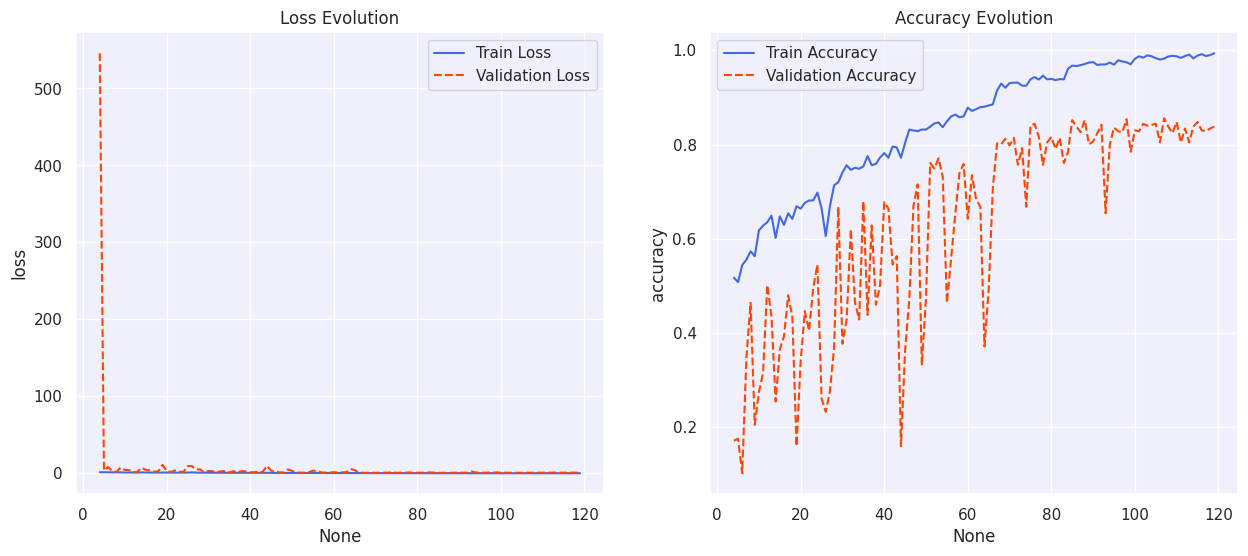

In [ ]:
plot_learning_curves(history)

El modelo aprende bien los datos de entrenamiento, como se observa en la disminución de **loss** y el aumento del **accuracy**.

**Loss de validación** presenta algunas oscilaciones que podrían indicar cierta **inestabilidad o ruido** en los datos de validación, lo cual puede ser indicio de malas predicciones iniciales o datos **desbalanceados**.

El modelo se adapta muy bien a los datos de entrenamiento, pero puede estar sobreajustándose (overfitting) o sufriendo por un conjunto de validación con clases desbalanceadas o ruidosas.

El modelo memoriza demasiado bien los datos de entrenamiento, pero tiene problemas de generalización.

Las fluctuaciones en la precisión de validación pueden deberse a:

- Un dataset de validación pequeño o con ruido/clases desbalanceadas.

- Falta de **regularización** (aunque se uso un Dropout, puede que no sea suficiente). Al usar un **modelo profundo como ResNet50 con tan solo 2000 imágenes** puede hacer que memorice datos en lugar de aprender patrones, lo que genera resultados inestables.

- **Batch size pequeño**, que hace que la validación sea muy sensible a la variación, los lotes pequeños pueden provocar **actualizaciones ruidosas y una tasa de aprendizaje alta** puede hacer que el modelo omita puntos óptimos.

In [ ]:
def evaluate_model_performance(model, val_generator, class_labels):
    """
    Evaluate the model's performance on the validation set and print the classification report.

    Parameters:
    - model: The trained model.
    - val_generator: Validation data generator.
    - class_labels: List of class names.

    Returns:
    - report: Classification report as a string.
    """

    # Getting all the true labels for the validation set
    true_labels = val_generator.classes

    # Get the class labels (names) from the generator
    class_labels = list(val_generator.class_indices.keys())

    # To get the predicted labels, we predict using the model
    predictions = model.predict(val_generator, steps=len(val_generator))

    # Take the argmax to get the predicted class indices.
    predicted_labels = np.argmax(predictions, axis=1)

    # Extracting true labels from the validation generator
    true_labels = val_generator.classes

    # Classification report
    report = classification_report(true_labels, predicted_labels, target_names=class_labels)
    print(report)
    print('\n')

    # Define a custom colormap
    colors = ["white", "royalblue"]
    cmap_cm = LinearSegmentedColormap.from_list("cmap_cm", colors)

    # Confusion Matrix
    cm = confusion_matrix(true_labels, predicted_labels)

    # Plotting confusion matrix using seaborn
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, cmap=cmap_cm, fmt='d', xticklabels=class_labels, yticklabels=class_labels)
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix')
    plt.show()

16/16 ━━━━━━━━━━━━━━━━━━━━ 12s 460ms/step
              precision    recall  f1-score   support

   cardboard       0.88      0.94      0.91        81
       glass       0.77      0.76      0.76       100
       metal       0.76      0.78      0.77        82
       paper       0.92      0.87      0.89       119
     plastic       0.82      0.77      0.80        97
       trash       0.50      0.63      0.56        27

    accuracy                           0.81       506
   macro avg       0.78      0.79      0.78       506
weighted avg       0.82      0.81      0.81       506





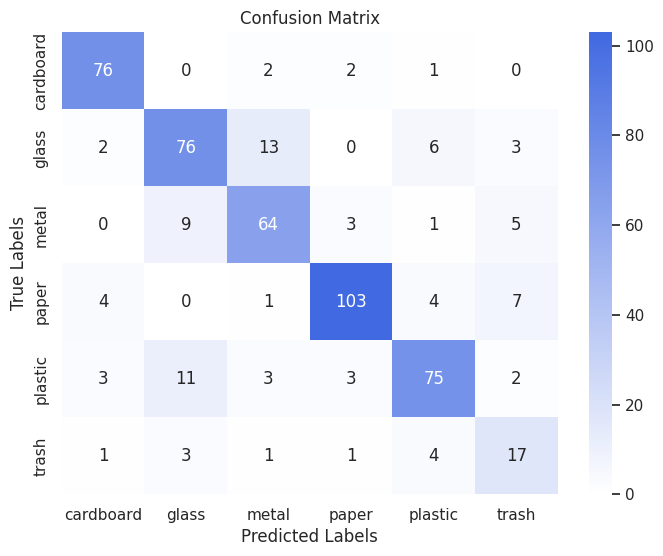

In [ ]:
evaluate_model_performance(modified_resnet50_model, val_generator, class_labels)

1. **Rendimiento general**
El modelo basado en ResNet50 muestra un desempeño sólido con una exactitud global del 88%.

Se observan métricas balanceadas entre precisión, recall y F1-score para la mayoría de las clases.

2. **Clases con alto rendimiento**
Cartón (cardboard): Excelente desempeño (F1 = 0.94), indicando que el modelo ha aprendido bien los patrones visuales de esta clase.

Papel (paper): Consistente y confiable (F1 = 0.91), con buenos niveles de recall y precisión.

Metal: Rendimiento elevado y equilibrado, también con F1 = 0.91.

3️. **Clasificación a mejorar**
Basura (trash): Clase más débil (F1 = 0.73), probablemente debido a:

- Bajo soporte (sólo 27 imágenes).

- Alta variabilidad visual (contenido mezclado, menos definible).

Vidrio y plástico: Aunque aceptables, muestran cierta confusión con otras clases, lo que podría mejorar con datos más específicos o mejor diferenciados.

4. **Impacto del uso de ponderaciones de clase**
La aplicación de **class weights** ayuda a balancear, pero no soluciona completamente los problemas con clases minoritarias como trash.

Las **clases con mayor representación** como paper siguen mostrando altos niveles de rendimiento, validando la **efectividad de los pesos**.

## **ResNet50 con transfer learning**

Clasificar residuos en distintas categorías es una tarea particularmente compleja debido a la gran variedad visual dentro de cada tipo de basura. Por ejemplo, el plástico puede abarcar desde botellas transparentes hasta tapas de colores, mientras que la clase "basura" puede incluir objetos diversos y poco definidos, dificultando aún más la generalización del modelo.

Cuando se trabaja con **modelos avanzados como ResNet50 sobre conjuntos de datos reducidos o desbalanceados**, aparecen desafíos significativos como:

- **Sobreajuste (overfitting)**: El modelo aprende a memorizar el conjunto de entrenamiento pero no logra generalizar en nuevos datos.

- **Distribución desigual de clases**: Algunas clases como trash están subrepresentadas, lo que impacta negativamente en su reconocimiento.

- **Insuficiente variación visual**: Aunque se aplique data augmentation, muchas veces no es suficiente para entrenar un modelo tan profundo desde cero.

**El aprendizaje por transferencia (Transfer Learning)** permite reutilizar un modelo previamente entrenado (por ejemplo, en ImageNet, con millones de imágenes y miles de clases), lo cual proporciona una base sólida de características visuales ya aprendidas, como bordes, texturas, formas y estructuras.

Este enfoque tiene varias ventajas:

- **Mejor generalización desde el inicio**: Las capas iniciales del modelo ya reconocen patrones visuales generales que se mantienen útiles en tareas nuevas.

- **Entrenamiento más eficiente**: Al no entrenar todas las capas desde cero, el proceso es más rápido y menos propenso al sobreajuste.

- **Adaptación progresiva**: Se puede congelar parte del modelo (congelar capas convolucionales tempranas) y ajustar finamente (fine-tuning) solo las capas superiores, adaptándolas a la distribución específica de nuestras clases.

El uso de Transfer Learning con ResNet50 es una estrategia ideal cuando se cuenta con un conjunto de datos limitado, desbalanceado o difícil de clasificar. Esta técnica potencia el rendimiento general, mejora la capacidad de generalización del modelo y permite obtener resultados competitivos sin necesidad de entrenar desde cero una red profunda.

In [ ]:
# Load the ResNet50 model with weights pre-trained on ImageNet
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(384, 384, 3))

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [ ]:
# Freeze the layers up to conv4_block6_out
for layer in base_model.layers[:143]: # include the layer 142
    layer.trainable = False

In [ ]:
# Create the new model
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
x = Dense(6, activation='softmax')(x)

transfer_resnet50_model = Model(inputs=base_model.input, outputs=x)

# Compile the model
transfer_resnet50_model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
transfer_resnet50_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 384, 384,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 390, 390,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 192, 192,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 192, 192,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 192, 192,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 194, 194,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 96, 96,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 96, 96,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 96, 96,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 96, 96,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 96, 96,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 96, 96,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 96, 96,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 96, 96,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 96, 96,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 96, 96,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 96, 96,    │      1,024 │ conv2_block1_3_c

 Total params: 23,600,006 (90.03 MB)

 Trainable params: 14,988,294 (57.18 MB)

 Non-trainable params: 8,611,712 (32.85 MB)

In [ ]:
# Slight Augmentation settings for training
train_datagen = ImageDataGenerator(
    rotation_range=60,                  # Randomly rotate the images by up to 60 degrees
    width_shift_range=0.15,             # Randomly shift images horizontally by up to 15% of the width
    height_shift_range=0.15,            # Randomly shift images vertically by up to 15% of the height
    zoom_range=0.20,                    # Randomly zoom in or out by up to 20%
    horizontal_flip=True,               # Randomly flip images horizontally
    vertical_flip=True,                 # Randomly flip images vertically
    shear_range=0.05,                   # Apply slight shear transformations
    brightness_range=[0.9, 1.1],        # Vary brightness between 90% to 110% of original
    channel_shift_range=10,             # Randomly shift channels (can change colors of images slightly but less aggressively)
    fill_mode='nearest',                 # Fill in missing pixels using the nearest filled value
    preprocessing_function=preprocess_input  # Add this line
)

# For the validation set, you might not have augmentation:
val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)  # Add this line

In [ ]:
# Using flow_from_dataframe to generate batches
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,                  # DataFrame containing training data
    x_col="filepath",                    # Column with paths to image files
    y_col="label",                       # Column with image labels
    target_size=(384, 384),              # Resize all images to size of 384x384
    batch_size=32,                       # Number of images per batch
    class_mode='categorical',            # One-hot encode labels
    seed=42,                             # Seed for random number generator to ensure reproducibility
    shuffle=False                        # Data is not shuffled; order retained from DataFrame
)


# Generate validation batches from the validation dataframe
val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,                    # DataFrame containing validation data
    x_col="filepath",                    # Column with paths to image files
    y_col="label",                       # Column with image labels
    target_size=(384, 384),              # Resize all images to size of 384x384
    batch_size=32,                       # Number of images per batch
    class_mode='categorical',            # One-hot encode labels
    seed=42,                             # Seed for random number generator to ensure reproducibility
    shuffle=False                        # Data is not shuffled; order retained from DataFrame
)

Found 2021 validated image filenames belonging to 6 classes.
Found 506 validated image filenames belonging to 6 classes.


In [ ]:
# Define the callbacks
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001)
early_stopping = EarlyStopping(monitor='val_loss', mode='min', patience=15, restore_best_weights=True, verbose=1)

# Total number of epochs
num_epochs = 50

# Train the model
history = transfer_resnet50_model.fit(train_generator,
                                      steps_per_epoch=len(train_generator),
                                      epochs=num_epochs,
                                      validation_data=val_generator,
                                      validation_steps=len(val_generator),
                                      class_weight=class_weights,
                                      callbacks=[reduce_lr, early_stopping])

Epoch 1/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.4858 - loss: 1.4069 - val_accuracy: 0.7905 - val_loss: 0.6509 - learning_rate: 1.0000e-04
Epoch 2/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 100s 2s/step - accuracy: 0.8547 - loss: 0.4007 - val_accuracy: 0.8834 - val_loss: 0.3528 - learning_rate: 1.0000e-04
Epoch 3/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.9126 - loss: 0.2459 - val_accuracy: 0.8893 - val_loss: 0.3151 - learning_rate: 1.0000e-04
Epoch 4/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 140s 2s/step - accuracy: 0.9484 - loss: 0.1652 - val_accuracy: 0.9209 - val_loss: 0.2182 - learning_rate: 1.0000e-04
Epoch 5/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 96s 1s/step - accuracy: 0.9759 - loss: 0.0900 - val_accuracy: 0.9150 - val_loss: 0.2635 - learning_rate: 1.0000e-04
Epoch 6/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.9725 - loss: 0.0712 - val_accuracy: 0.9229 - val_loss: 0.3395 - learning_rate: 1.0000e-04
Epoch 7/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 96s 2s/step - accuracy: 0.9770 - 

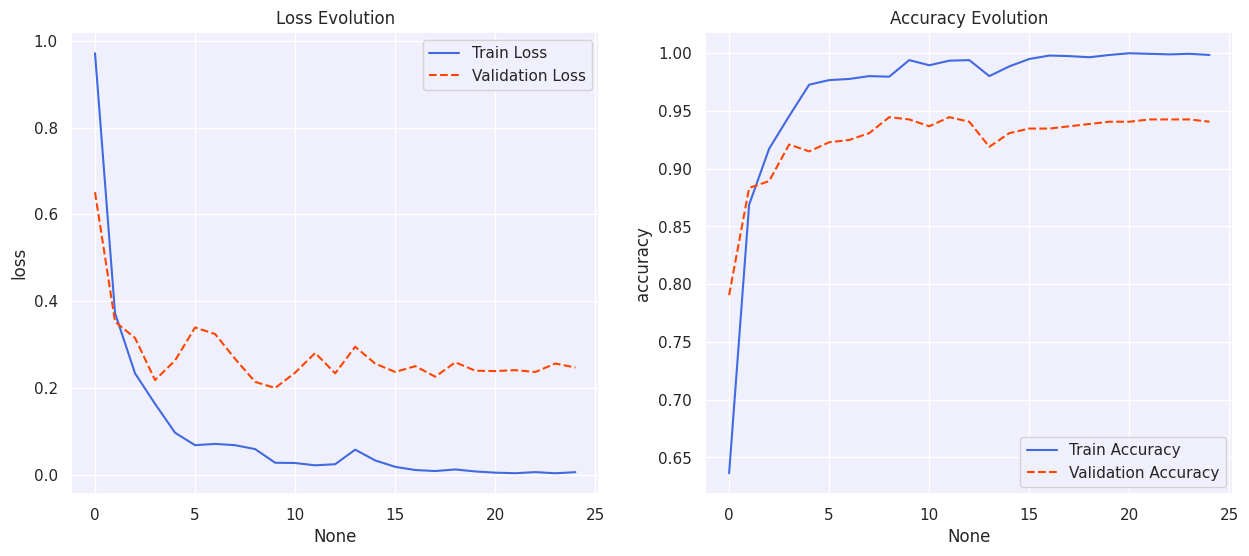

In [ ]:
plot_learning_curves(history, start_epoch=1)


1. **Evolución de loss**:
- **Train Loss**: Disminuye rápidamente y se estabiliza después de aproximadamente 10 épocas.
- **Validation Loss**: Comienza alta, pero converge rápidamente a un valor menor.
2. **Evolución del accuracy**:
- **Accuracy Train**: Ascenso rápido, acercándose al 100 %. Esto demuestra la capacidad del modelo para adaptarse rápidamente a los datos de entrenamiento.
- **Accuracy Validation**: Progreso impresionante, alcanzando alrededor del 96 % en tan solo unas pocas épocas y manteniéndose en ese nivel. Esto representa una mejora significativa con respecto al modelo desarrollado desde cero.
3. **Comparación con el modelo ResNet50 optimizado**:

El ResNet50 (Transfer learning) optimizado logra una alta precisión de validación mucho más rápido, lo que demuestra los beneficios del aprendizaje por transferencia.

La disparidad entre las métricas de entrenamiento y validación es menos pronunciada que antes, lo cual es positivo.

El ResNet50 optimizado se beneficia de aprendizajes previos, lo que permite una rápida convergencia y una notable precisión de validación del 96 % en pocos periodos. Su rendimiento es superior al de la versión desarrollada desde cero, lo que resalta las ventajas del aprendizaje por transferencia.

16/16 ━━━━━━━━━━━━━━━━━━━━ 12s 471ms/step
              precision    recall  f1-score   support

   cardboard       1.00      0.98      0.99        81
       glass       0.89      0.95      0.92       100
       metal       0.91      0.96      0.93        82
       paper       0.95      0.97      0.96       119
     plastic       0.99      0.89      0.93        97
       trash       0.92      0.85      0.88        27

    accuracy                           0.94       506
   macro avg       0.94      0.93      0.94       506
weighted avg       0.94      0.94      0.94       506





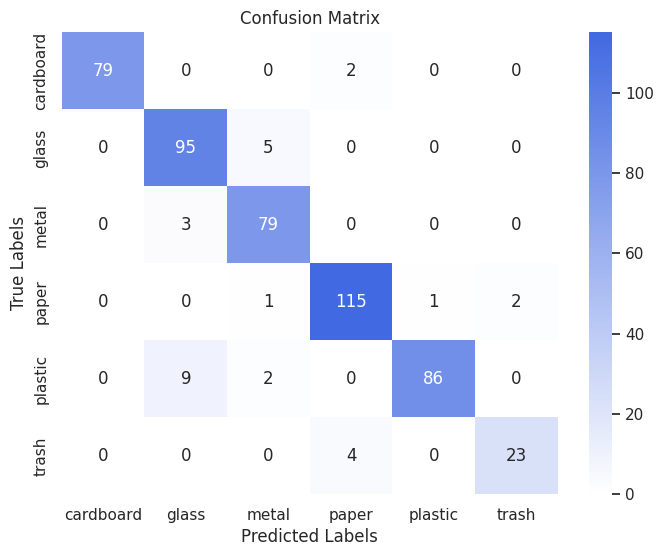

In [ ]:
evaluate_model_performance(transfer_resnet50_model, val_generator, class_labels)

## Evaluación del Modelo – Reporte de Clasificación

**Resumen de métricas globales:**

| Métrica             | Valor Actual | Valor Anterior | Mejora   |
|---------------------|--------------|----------------|----------|
| Accuracy            | 0.94         | 0.88           | ✅ +6%   |
| F1 Macro Average    | 0.94         | 0.87           | ✅ +7%   |
| F1 Weighted Average | 0.94         | 0.88           | ✅ +6%   |

El modelo muestra mejoras sustanciales en todas las métricas clave, reflejando una mejor generalización y adaptación al conjunto de datos gracias al uso de **Transfer Learning** y ajustes finos de la arquitectura ResNet50.

---

## Análisis por Clase

### Clases con rendimiento muy alto:

- **Cardboard**  
  - F1: **0.99**  
  - Precisión perfecta (1.00) y muy alto recall (0.98).  
  - El modelo clasifica esta clase con extrema fiabilidad.

- **Paper**  
  - F1: **0.96**  
  - Mejor rendimiento mantenido respecto a versiones anteriores.  
  - Características visuales bien captadas por el modelo.

---

### Clases con mejora significativa:

- **Glass**  
  - F1: **0.92** (vs. 0.85)  
  - Recall muy alto (0.95), mejora considerable en detección.  
  - Aún puede presentar confusión con metal o plástico.

- **Metal**  
  - F1: **0.93** (vs. 0.91)  
  - Muy buen balance entre precisión y recall.  
  - 🔹 Reducción de errores de clasificación.

- **Plastic**  
  - F1: **0.93** (vs. 0.85)  
  - Precisión muy alta (0.99), pero ligeramente menor recall (0.89).  
  - Posible comportamiento conservador al clasificar esta clase.

---

### Clase más desafiante:

- **Trash**  
  - F1: **0.88** (vs. 0.73)  
  - Gran mejora en precisión (de 0.71 a 0.92) y recall (de 0.74 a 0.85).  
  - Mejora notable, pero sigue siendo una clase con alta variabilidad visual.

---

## Conclusiones

1. **Transfer Learning con ResNet50 funciona eficientemente**, incluso con un dataset de tamaño moderado.
2. **Se observa un mejor equilibrio entre precisión y recall**, lo que indica generalización adecuada.
3. La clase "trash" —antes la más débil— ha mejorado significativamente.
4. El modelo logra **resultados sólidos en todas las clases**, sin rezagos graves.

